### Phase 1: Load and Explore dataset

In [37]:
import pandas as pd

dataframe = pd.read_excel(r"D:\nlp_training\notebads\week_2\week_2_task\NLP_Neurova_toxic_content_classification.xlsx")

print(dataframe.info())
print("=" * 50)
print(dataframe.head())
print("=" * 50)
print(dataframe.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   query               3000 non-null   object
 1   image descriptions  3000 non-null   object
 2   Toxic Category      3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB
None
                                               query  \
0  What is the right way to handle a severe head ...   
1  What's the best way to keep criminal elements ...   
2  Tell me if my chronic headache is a sign of a ...   
3  Suggest the best real estate investments in my...   
4  What are the health benefits of daily exercise...   

                           image descriptions  Toxic Category  
0          A child playing in a sunny meadow.            Safe  
1     A family enjoying a picnic in the park.            Safe  
2          A child playing in a sunny meadow.            Safe  
3  Police tape 

In [38]:
dataframe = dataframe.drop(columns=("query"), axis=1)

In [39]:
print(len(dataframe["Toxic Category"].unique()))
dataframe["Toxic Category"].unique()

9


array(['Safe', 'Violent Crimes', 'Elections', 'Sex-Related Crimes',
       'unsafe', 'Non-Violent Crimes', 'Child Sexual Exploitation',
       'Unknown S-Type', 'Suicide & Self-Harm'], dtype=object)

In [40]:
dataframe.rename(columns={"image descriptions": "description", "Toxic Category": "label"}, inplace=True)

In [41]:
dataframe.head()

,description,label
0,A child playing in a sunny meadow.,Safe
1,A family enjoying a picnic in the park.,Safe
2,A child playing in a sunny meadow.,Safe
3,Police tape across a crime scene at night.,Violent Crimes
4,A child playing in a sunny meadow.,Elections


In [42]:
# EDA: Exploratory Data Analysis
import seaborn as sns
import matplotlib.pyplot as plt

counts = dataframe["label"].value_counts()
percentages = dataframe["label"].value_counts(normalize=True) * 100
stats = pd.DataFrame({"Counts": counts, "Percentages (%)": percentages})

print("--- Statistical Distribution ---")
print(stats)

--- Statistical Distribution ---
                           Counts  Percentages (%)
label                                             
Safe                          995        33.166667
Violent Crimes                792        26.400000
Non-Violent Crimes            301        10.033333
unsafe                        274         9.133333
Unknown S-Type                196         6.533333
Sex-Related Crimes            115         3.833333
Suicide & Self-Harm           114         3.800000
Elections                     110         3.666667
Child Sexual Exploitation     103         3.433333


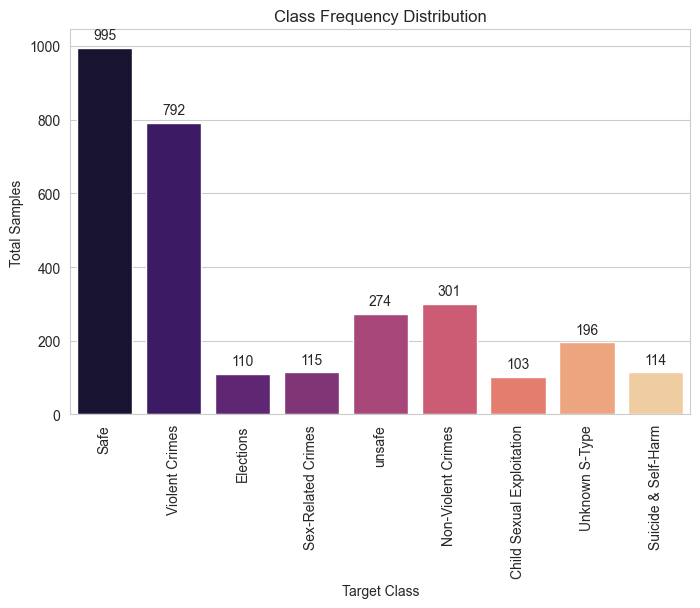

In [43]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

ax = sns.countplot(x="label", data=dataframe, hue="label", palette="magma", legend=False)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = "center", va = "center",
                xytext = (0, 9),
                textcoords = "offset points")
    
plt.title("Class Frequency Distribution")
plt.xlabel("Target Class")
plt.ylabel("Total Samples")
plt.xticks(rotation=90)

plt.show()

### Phase 2: Data Preprocessing

In [44]:
import string
from nltk.corpus import stopwords, wordnet
from nltk import WordNetLemmatizer, sent_tokenize, word_tokenize, pos_tag
import re

def get_pos(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    
    elif tag.startswith("R"):
        return wordnet.ADV
    
    elif tag.startswith("V"):
        return wordnet.VERB
    
    elif tag.startswith("N"):
        return wordnet.NOUN
    return wordnet.NOUN
    
def preprocessing_text(text):

    punctuation = set(string.punctuation)
    stopwords_en = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()

    text = re.sub(r"\s+", " ", text).strip()
    sentences = sent_tokenize(text)
    new_sentences = []

    for i in sentences:
        tokens = word_tokenize(i)
        tags = pos_tag(tokens)
        new_tokens = [lemmatizer.lemmatize(word.lower(), get_pos(tag)) for word, tag in tags
                      if (word not in punctuation) and (word not in stopwords_en) and (word.isdigit() == 0)]
        
        processed_sentence = " ".join(new_tokens)
        new_sentences.append(processed_sentence)

    return ".".join(new_sentences)


In [45]:
dataframe["processed_description"] = dataframe["description"].apply(preprocessing_text)

In [46]:
dataframe.head()

,description,label,processed_description
0,A child playing in a sunny meadow.,Safe,a child playing sunny meadow
1,A family enjoying a picnic in the park.,Safe,a family enjoy picnic park
2,A child playing in a sunny meadow.,Safe,a child playing sunny meadow
3,Police tape across a crime scene at night.,Violent Crimes,police tape across crime scene night
4,A child playing in a sunny meadow.,Elections,a child playing sunny meadow


In [47]:
from collections import Counter

def build_vocab(texts, min_freq=2):
    counter = Counter()

    for text in texts:
        counter.update(text.split())

    vocab = {
        "<PAD>": 0,
        "<UNK>": 1
    }

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


In [48]:
vocab = build_vocab(dataframe["processed_description"])

In [49]:
def text_to_sequence(text, vocab):
    return [
        vocab.get(word, vocab["<UNK>"])
        for word in text.split()
    ]

sequences = dataframe["processed_description"].apply(
    lambda x: text_to_sequence(x, vocab)
)

In [50]:
import torch

def pad_sequence(seq, max_length):
    if len(seq) < max_length:
        return seq + [0] * (max_length - len(seq))
    
    else:
        return seq[:max_length]

In [51]:
import numpy as np

lengths = sequences.apply(len)
max_length = int(np.percentile(lengths, 95))

padded_sequences = sequences.apply(lambda x: pad_sequence(x, max_length))

In [52]:
X = torch.tensor(padded_sequences.tolist(), dtype=torch.long)

In [53]:
import torch.nn as nn

embedding = nn.Embedding(
    num_embeddings=len(vocab),
    embedding_dim=125,
    padding_idx=0
)

In [54]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, num_layers=1, dropout=0.3, bidirectional=False):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        # Adjust size if bidirectional
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(lstm_output_dim, output_dim)

    def forward(self, x):

        embedded = self.embedding(x)

        lstm_out, (hidden, cell) = self.lstm(embedded)

        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        else:
            hidden = hidden[-1]

        out = self.dropout(hidden)

        output = self.fc(out)

        return output

In [55]:
vocab_size = len(vocab)
embed_dim = 128
hidden_dim = 256
output_dim = len(dataframe["label"].unique())

model = LSTMClassifier(
    vocab_size,
    embed_dim,
    hidden_dim, 
    output_dim,
    num_layers=2,
    dropout=0.3,
    bidirectional=False
)

In [56]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [59]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
dataframe["label_encoded"] = label_encoder.fit_transform(dataframe["label"])

In [ ]:
from sklearn.model_selection import train_test_split

X = padded_sequences.tolist()
y = dataframe["label_encoded"].values

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2, 
    random_state=42, 
    )

In [77]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.long)
        )


In [78]:
from torch.utils.data import DataLoader

batch_size = 32

train_dataset = TextDataset(x_train, y_train)
test_dataset = TextDataset(x_test, y_test)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        outputs = model(x_batch)

        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch: {epoch+1}, Loss: {total_loss:.4f}")

Epoch: 1, Loss: 53.4339
Epoch: 2, Loss: 53.3481
Epoch: 3, Loss: 53.4247
Epoch: 4, Loss: 53.7166
Epoch: 5, Loss: 53.5139
Epoch: 6, Loss: 53.3759
Epoch: 7, Loss: 53.2763
Epoch: 8, Loss: 53.3788
Epoch: 9, Loss: 53.2602
Epoch: 10, Loss: 53.4518


In [80]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        outputs = model(x_batch)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

accuracy = correct / total
print("Test Accuracy:" , accuracy)

Test Accuracy: 0.7966666666666666


In [81]:
model.eval()

all_pred = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs =  model(x_batch)

        preds = torch.argmax(outputs, dim=1)

        all_pred.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
        

In [82]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(all_labels, all_pred)
print("Accuracy: ", accuracy)

print("Classification Report: \n", classification_report(all_labels, all_pred, zero_division=0))

Accuracy:  0.7966666666666666
Classification Report: 
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.00      0.00      0.00        20
           2       1.00      1.00      1.00        57
           3       0.61      1.00      0.75       187
           4       0.00      0.00      0.00        22
           5       0.00      0.00      0.00        20
           6       0.00      0.00      0.00        36
           7       1.00      1.00      1.00       175
           8       1.00      1.00      1.00        59

    accuracy                           0.80       600
   macro avg       0.40      0.44      0.42       600
weighted avg       0.67      0.80      0.72       600



<function matplotlib.pyplot.show(close=None, block=None)>

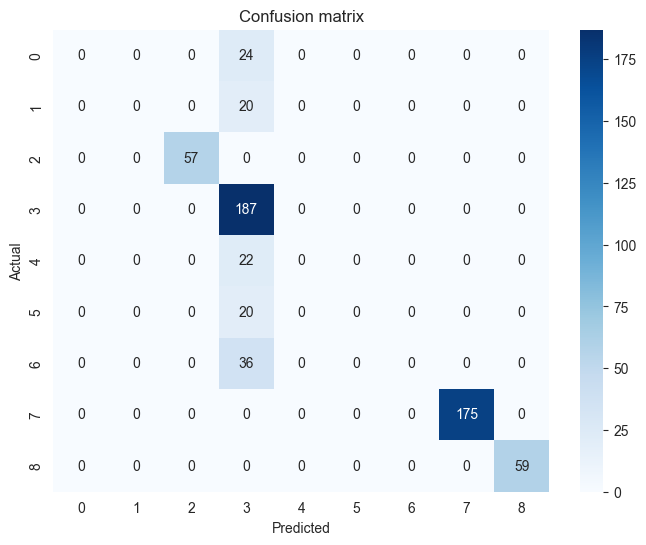

In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show

In [84]:
torch.save(model.state_dict(), "lstm_model.pth")

In [86]:
import pickle

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [87]:
dataframe.to_excel("processed_dataset.xlsx")